In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ablation-study/fault_times.json
/kaggle/input/ablation-study/option2_gnn_metrics.json
/kaggle/input/ablation-study/gnn_training_snapshots.pt
/kaggle/input/ablation-study/synthetic_ground_truth.csv
/kaggle/input/ablation-study/synthetic_sensor_logs.txt
/kaggle/input/ablation-study/gnn_option2_weights.pt
/kaggle/input/ablation-study/adjacency.npy
/kaggle/input/ablation-study/synthetic_ground_truth_eval.csv
/kaggle/input/ablation-study/df_faulty_adv.csv


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [3]:
DEVICE = "cpu"
EPOCHS = 60
LR = 1e-3
LAMBDA_R = 1.0   # consistency weight (tunable, but start with 1)


In [4]:
NODE_IDS = [0, 1, 2, 3, 4, 101]
NODE_TO_IDX = {n: i for i, n in enumerate(NODE_IDS)}
NUM_NODES = len(NODE_IDS)


In [5]:
A_norm = np.load("/kaggle/input/ablation-study/adjacency.npy")
A = torch.tensor(A_norm, dtype=torch.float32)


In [6]:
df_faulty = pd.read_csv("/kaggle/input/ablation-study/df_faulty_adv.csv")


In [7]:
df_moisture = df_faulty[
    (df_faulty.modality == "moisture") &
    (df_faulty.probe.isin(["M1", "M2"]))
]


In [8]:
wide = (
    df_moisture
    .pivot_table(
        index=["time_index", "sender"],
        columns="probe",
        values="value",
        aggfunc="mean"   # safe even if duplicates exist
    )
    .dropna()
    .reset_index()
)


wide["probe_disagreement"] = (wide["M1"] - wide["M2"]).abs()
wide["theta_mean"] = wide[["M1", "M2"]].mean(axis=1)


In [9]:
print(wide[["M1","M2"]].describe())


probe          M1          M2
count  244.000000  244.000000
mean    61.909426   65.863955
std     21.132500   23.450689
min     28.140000   37.890000
25%     45.855000   47.762500
50%     53.525000   55.425000
75%     75.765000   75.737500
max    100.680000  113.270000


In [10]:
wide = wide.sort_values(["sender", "time_index"])
wide["delta_theta"] = (
    wide.groupby("sender")["theta_mean"]
    .diff()
    .fillna(0.0)
)


In [11]:
FEATURE_COLUMNS = ["theta_mean", "probe_disagreement", "delta_theta"]


In [12]:
def build_snapshots(df):
    snapshots = []

    for t in sorted(df.time_index.unique()):
        df_t = df[df.time_index == t]

        x = torch.zeros((NUM_NODES, len(FEATURE_COLUMNS)))
        m1 = torch.full((NUM_NODES,), float("nan"))
        m2 = torch.full((NUM_NODES,), float("nan"))


        for _, row in df_t.iterrows():
            idx = NODE_TO_IDX[row.sender]
            x[idx] = torch.tensor(
                row[FEATURE_COLUMNS].values,
                dtype=torch.float32
            )
            m1[idx] = row.M1
            m2[idx] = row.M2

        snapshots.append({
            "x": x,
            "m1": m1,
            "m2": m2
        })

    return snapshots


In [13]:
print(wide[["M1", "M2"]].describe())


probe          M1          M2
count  244.000000  244.000000
mean    61.909426   65.863955
std     21.132500   23.450689
min     28.140000   37.890000
25%     45.855000   47.762500
50%     53.525000   55.425000
75%     75.765000   75.737500
max    100.680000  113.270000


In [14]:
print(df_faulty["probe"].unique())


['M1' 'M2' 'R' 'T1' 'T2' 'P']


In [15]:
snapshots = build_snapshots(wide)


In [16]:
class ConsistencyAwareGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc_theta = nn.Linear(hidden_dim, 1)
        self.fc_r = nn.Linear(hidden_dim, 1)

    def forward(self, x, A):
        h = torch.matmul(A, x)
        h = F.relu(self.fc1(h))

        theta_hat = self.fc_theta(h).squeeze()
        r_raw = self.fc_r(h).squeeze()
        r_hat = torch.relu(self.fc_r(h).squeeze())



        return theta_hat, r_hat


In [17]:
def consistency_loss_c5(theta_hat, r_hat, m1, m2,
                        lambda_r,
                        margin=5.0,
                        lambda_sparse=0.05):
    valid = ~torch.isnan(m1) & ~torch.isnan(m2)

    if valid.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)

    # 1️⃣ State consistency (unchanged)
    loss_theta = (
        (m1[valid] - theta_hat[valid])**2 +
        (m2[valid] - theta_hat[valid])**2
    ).mean()

    # 2️⃣ True probe inconsistency
    true_r = (m1[valid] - m2[valid]).abs()

    # 3️⃣ Margin loss
    loss_margin = torch.mean(
        torch.where(
            true_r < margin,
            r_hat[valid]**2,
            (torch.relu(margin - r_hat[valid]))**2
        )
    )

    # 4️⃣ SPARSITY PRESSURE (THIS IS THE FIX)
    loss_sparse = r_hat.mean()

    return loss_theta + lambda_r * loss_margin + lambda_sparse * loss_sparse


In [18]:
valid_counts = []

for snap in snapshots:
    valid = ~torch.isnan(snap["m1"]) & ~torch.isnan(snap["m2"])
    valid_counts.append(valid.sum().item())

print("Min valid probes per snapshot:", min(valid_counts))
print("Max valid probes per snapshot:", max(valid_counts))
print("Snapshots with ZERO valid probes:",
      sum(v == 0 for v in valid_counts))


Min valid probes per snapshot: 1
Max valid probes per snapshot: 3
Snapshots with ZERO valid probes: 0


In [19]:
model = ConsistencyAwareGNN(
    in_dim=len(FEATURE_COLUMNS)
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)


In [20]:
for epoch in range(EPOCHS):
    losses = []

    for snap in snapshots:
        optimizer.zero_grad()

        theta_hat, r_hat = model(snap["x"], A)
        loss = consistency_loss_c5(
            theta_hat,
            r_hat,
            snap["m1"],
            snap["m2"],
            lambda_r=LAMBDA_R,
            margin=5.0,
            lambda_sparse=0.05
        )




        
        if torch.isnan(loss):
            print("NaN loss at snapshot — skipping")
            continue


        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {np.mean(losses):.4f}")


Epoch 000 | Loss: 6552.4958
Epoch 010 | Loss: 1500.1530
Epoch 020 | Loss: 1390.4509
Epoch 030 | Loss: 1254.5497
Epoch 040 | Loss: 1134.0259
Epoch 050 | Loss: 1045.9541


In [21]:
with torch.no_grad():
    snap = snapshots[len(snapshots)//2]
    _, r_hat = model(snap["x"], A)

print("r_hat stats:",
      r_hat.min().item(),
      r_hat.mean().item(),
      r_hat.max().item())


r_hat stats: 0.0 0.0 0.0


In [22]:
import json
with open("/kaggle/input/ablation-study/fault_times.json") as f:
    fault_times = set(json.load(f))


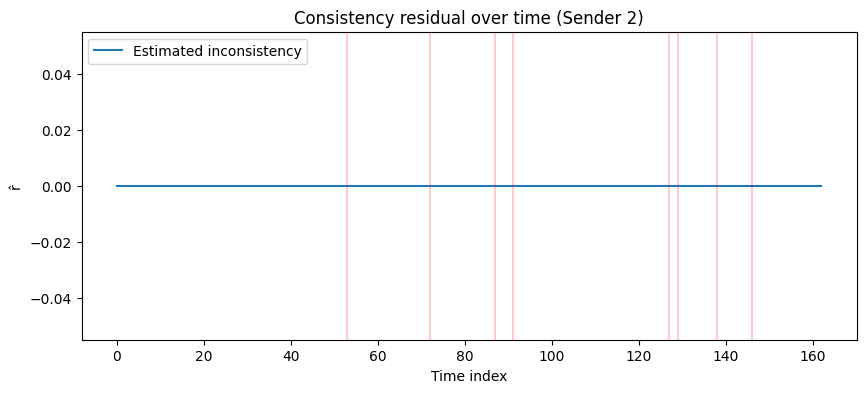

In [23]:
r_series = []
for t, snap in enumerate(snapshots):
    with torch.no_grad():
        _, r_hat = model(snap["x"], A)
    r_series.append(r_hat[NODE_TO_IDX[2]].item())

plt.figure(figsize=(10,4))
plt.plot(r_series, label="Estimated inconsistency")

for t in fault_times:
    plt.axvline(t, color="red", alpha=0.2)

plt.title("Consistency residual over time (Sender 2)")
plt.xlabel("Time index")
plt.ylabel("r̂")
plt.legend()
plt.show()
